In [81]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, r2_score
from sklearn.ensemble import RandomForestClassifier,  RandomForestRegressor, BaggingClassifier

In [25]:
# Loading dataset
titanic = sns.load_dataset("titanic")

feature = ["pclass","sex","fare","embarked","age"]
target = ["survived"]

In [26]:
# Fill missing age
imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

# Fill missing embarked
imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [27]:
# encoding
le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [28]:
# Train test split
X = titanic[feature]
y = titanic[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42)

In [86]:
# Decision Tree

model = DecisionTreeClassifier(max_depth=2)
model.fit(X_train, y_train)

y_pred_test = model.predict(X_test)
y_pred_train = model.predict(X_train)

print(f"Training Accuracy: {accuracy_score(y_train,y_pred_train):.4f}")
print(f"Testing Accuracy: {accuracy_score(y_test,y_pred_test):.4f}")

Training Accuracy: 0.8034
Testing Accuracy: 0.7654


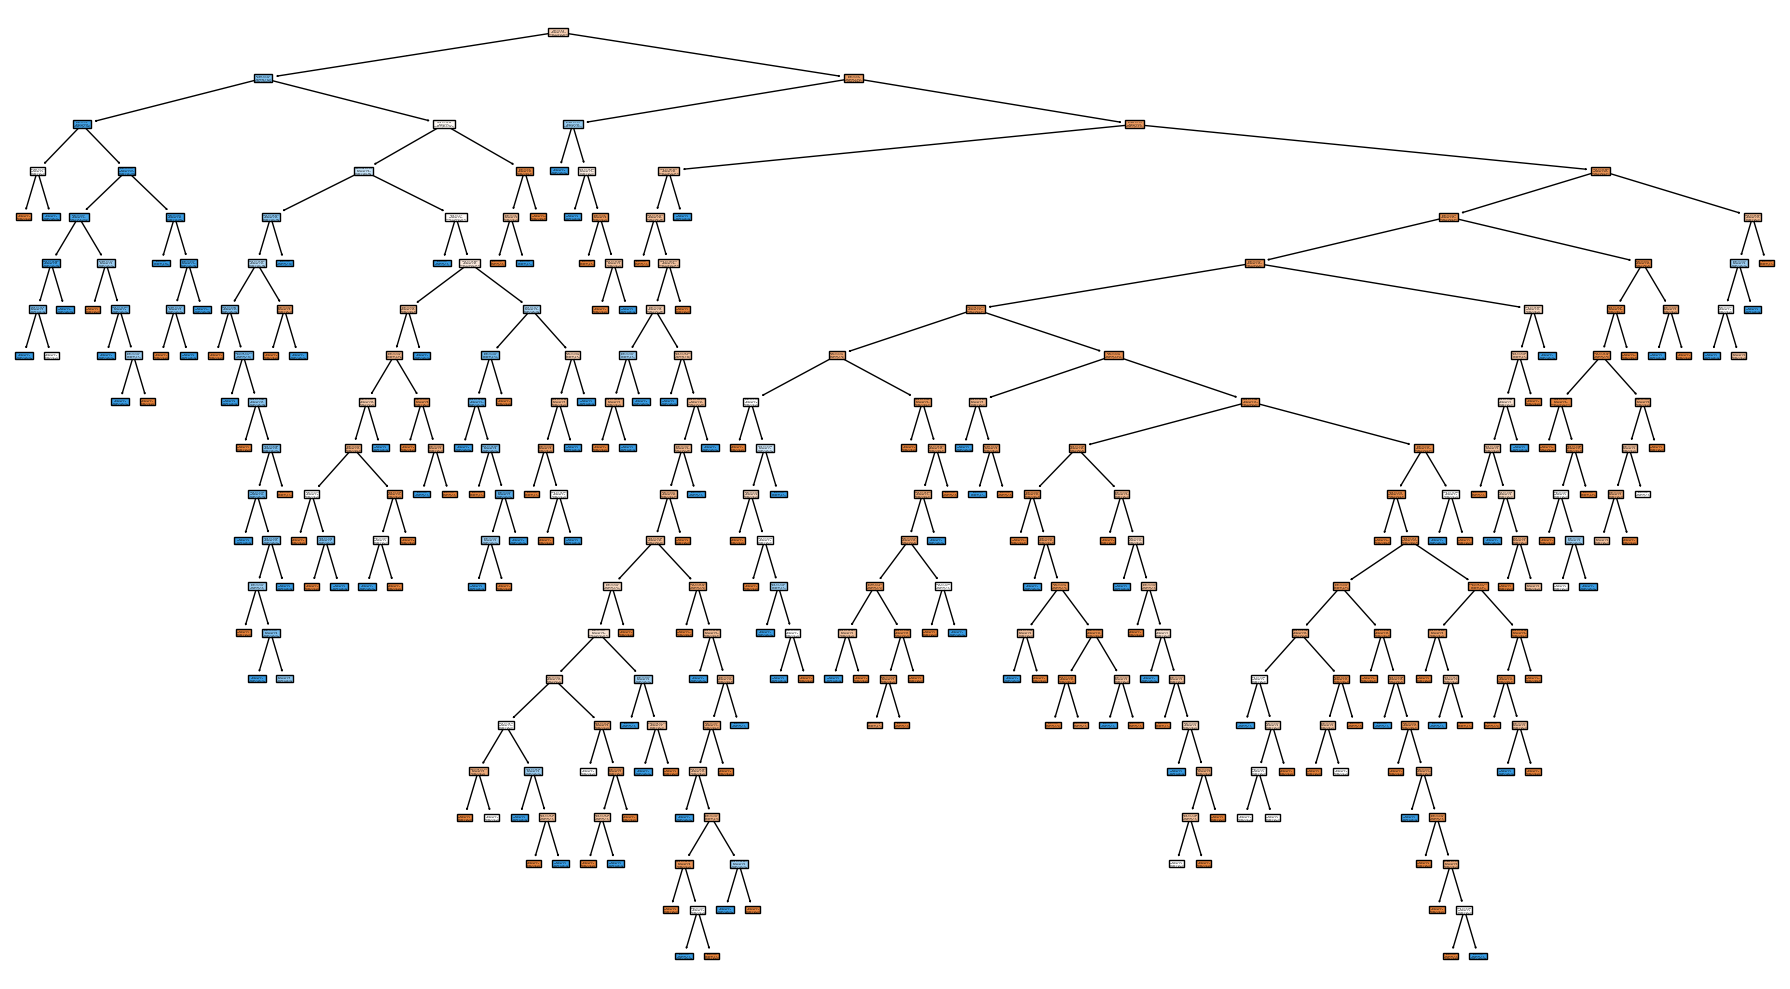

In [85]:
# Ploting tree
plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","survived"],
    filled=True
)
plt.tight_layout()

In [83]:
# Random Forest Classifier
rf = RandomForestClassifier(
    n_estimators=501,
    oob_score=True,
    bootstrap=True,
    max_depth=4
)
rf.fit(X_train,y_train.values.ravel())
y_pred = rf.predict(X_test)
    
print(f"OOB score: {(rf.oob_score_)*100:.4f} %")
print(f"Testing Accuracy: {accuracy_score(y_test,y_pred)*100:.4f} %")


OOB score: 82.1629 %
Testing Accuracy: 81.5642 %


In [68]:
 # Decision Tree
base_model = DecisionTreeClassifier()
bagging = BaggingClassifier(
    base_model,
    n_estimators=201
)
bagging.fit(X_train, y_train.values.ravel())
y_pred_test = bagging.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_train,y_pred_train):.4f}")

Accuracy Score: 0.8399
